# PROJEKT : <span style="margin-left:40px;"> Jerzy Marcin Urbański</span>

##### TEMAT:
## Analiza Jakości Powietrza Dla Wybranych Lokalizacji Oraz Okresów

Importy Bibliotek wraz z ich opisem 

<hr style="border: none; border-top: 11px dotted green;">

Sekcja bibliotek

<hr style="border: none; border-top: 11px dashed black;">

<hr style="
height:6px;
border:none;
background: linear-gradient(to right, red, orange, yellow, green, blue, purple);
">

<div style="
height:50px;
width:100%;
background: linear-gradient(270deg, red, orange, yellow, green, blue, purple);
background-size: 400% 100%;
animation: gradientMove 5s ease infinite;
"></div>

<style>
@keyframes gradientMove {
  0% { background-position: 0% 50%; }
  100% { background-position: 100% 50%; }
}
</style>

In [4]:
# ### pandas

# Biblioteka do pracy z danymi tabelarycznymi (DataFrame), umożliwia łatwe filtrowanie, grupowanie i przekształcanie danych. 
# Używana głównie do analizy danych, czyszczenia danych oraz wczytywania/zapisywania plików (CSV, Excel, SQL).
import pandas as pd

# ### numpy
# Podstawowa biblioteka do obliczeń numerycznych w Pythonie, oferująca wydajne operacje na tablicach wielowymiarowych. 
# Wykorzystywana do obliczeń matematycznych, statystycznych oraz jako fundament dla innych bibliotek analitycznych.
import numpy as np

# ### os
# Biblioteka standardowa do interakcji z systemem operacyjnym, umożliwia pracę z plikami i katalogami oraz zmiennymi środowiskowymi. 
#Używana m.in. do automatyzacji operacji na plikach i zarządzania ścieżkami.
import os

# ### matplotlib
# Biblioteka do tworzenia wykresów i wizualizacji danych w Pythonie. Pozwala generować różne typy wykresów (liniowe, słupkowe, histogramy) 
# oraz dostosowywać ich wygląd.
import matplotlib.pyplot as plt

# ### seaborn
# Rozszerzenie matplotlib, które upraszcza tworzenie estetycznych i statystycznych wizualizacji danych. 
# Umożliwia szybkie generowanie wykresów takich jak heatmapy, wykresy rozkładu czy zależności między zmiennymi.
import seaborn as sns

# ### ydata_profiling
# Biblioteka do automatycznej analizy eksploracyjnej danych (EDA), generująca szczegółowe raporty o zbiorze danych. 
# Pokazuje statystyki, brakujące wartości, korelacje i potencjalne problemy w danych.
from ydata_profiling import ProfileReport

# ### IPython.display
# Moduł umożliwiający wyświetlanie różnych typów treści w notebookach (HTML, obrazy, wideo). 
#  Używany do wzbogacania prezentacji wyników analiz i tworzenia interaktywnych raportów.
from IPython.display import IFrame

# Moduł do obsługi ścieżek plików
from pathlib import Path

Sekcja bibliotek ML

In [6]:
# import....

## STEP 1. Wczytanie danych + transformacja datasetów przygotowanie do głównego połaczenia.
        [ LOAD DATA + PREPROCESSING ]
Import danych z plików csv , ostateczne sprawdznie oraz potrzebna agregacja do ostatecznej wersji.

### 1.1. - DANE - weather_pz/ld_2023/2024

##### 1.1.1. Import wszyskich plików do odpowiednich zmiennych 


In [10]:
# import wszyskich plików do odpowiednich zmiennych 

w_ld_2023 = pd.read_csv('/Users/marcinurbanski/Desktop/jmu_repo/1_projekt_air_polution_repo/0_ready_raw_data/weather_ld_2023.csv')
w_ld_2024 = pd.read_csv('/Users/marcinurbanski/Desktop/jmu_repo/1_projekt_air_polution_repo/0_ready_raw_data/weather_ld_2024.csv')
w_pz_2023 = pd.read_csv('/Users/marcinurbanski/Desktop/jmu_repo/1_projekt_air_polution_repo/0_ready_raw_data/weather_pz_2023.csv')
w_pz_2024 = pd.read_csv('/Users/marcinurbanski/Desktop/jmu_repo/1_projekt_air_polution_repo/0_ready_raw_data/weather_pz_2024.csv')

In [11]:
# szybkie sprawdznie 

# display(w_ld_2023.head(2))
# display(w_ld_2024.head(2))
# display(w_pz_2023.head(2))
# display(w_pz_2024.head(2))

#### 1.1.2. Połaczenie w jedne DataFrame

In [13]:
w_df = pd.concat([w_ld_2023,w_ld_2024,w_pz_2023,w_pz_2024], axis=0 , ignore_index=True)

#### 1.1.2. - Agregacja danych do postaci uniwersalnego DataFrame 

In [15]:
# przypisanie odpowiedniego id miasta [city] wg współrzędnych

w_df['city'] = w_df['longitude'].map({17.0 : 'PZ' , 19.5 : 'LD'})

In [16]:
# Selekscja kolumn do usunięcia 

# print(w_ld_2004['step'].nunique()) # kolumna ma jeden wynik -> usunać
# print('-'*140)
# print(w_ld_2004['surface'].nunique()) # kolumna ma jeden wynik -> usunać
# print('-'*140)
# print(w_ld_2004[w_ld_2004["time"] != w_ld_2004["valid_time"]]) # kolumna 'valid_time' powtrza wartosci 'time' -> usunać 
# print('-'*140)
# print(w_ld_2004['number'].nunique())

In [17]:
# usunięcie niepotrzebnych kolumn ['Unnamed: 0','latitude','longitude','step','surface','valid_time']

w_df = w_df.drop(['Unnamed: 0','latitude','longitude','step','surface','valid_time','number'], axis=1)

In [18]:
# Zamiana typu danych object z kolumny 'time' na date_time

w_df['time'] = pd.to_datetime(w_df['time'])

Obliczenie prędkości wiatru ze zmiennych u10 & v10 ze wzoru tj z równania pitagorasa
- zmienna u10 => prędkość wiatru zachodniego 
- zmienna v10 => prędkość wiartu północnego 

$$
v_w = \sqrt{u_{10}^2 + v_{10}^2}
$$


In [20]:
# przeliczenie prędkości wiatru 'v_w' i dodanie jako nowa kolumna z tymi wartościami

w_df['v_w'] = np.sqrt(w_df['u10']**2 + w_df['v10']**2)

In [21]:
# ułożenie kolejnosci kolumn [info data | zmienne pogodowe] 

col_order = ['city','time','u10', 'v10','v_w','t2m','blh','sp','tcc']
w_df = w_df[col_order]

#### 1.1.4. PODSUMOWANIE PKT. 1.1 DANE POGOWE 
OPIS ZMIENNYCH 
- 'city' -> MIASTO ZAPISANE W SYMOBOLEM
    - PZ = Poznań
    - LD = Łódź 
- 'time'............ DATA GODZINA
- 'u10' -> predkosc wiatru z kierunku / jednostko = [ m/s ] 
- 'v10' -> prędkość wiatru z kierunku / jednostka = [ m/s ]
- 'v_w' -> rzeczywista prędkość wiatru / jednostka = [ m/s ]
- 't2m' -> temperatura powietrze 2m nad poziomem powierzchni / jednostka [ Kelwin ]
- 'blh' -> WYSOKOŚĆ WARSTWY GRANICZNEJ / jednostka [ m ]
- 'sp' -> CIŚNIENIE / jednostka [ Pa ]
- 'tcc' -> CAŁKOWITE ZACHMURZENIE / jednostk [ 0-1 ] [ % ]

    

### 1.2. TABELE CAŁKOWITE OPADY - total_precipition

#### 1.2.1. Import wszyskich plików do odpowiednich zmiennych 

In [25]:
tp_ld_2004 = pd.read_csv('/Users/marcinurbanski/Desktop/jmu_repo/1_projekt_air_polution_repo/0_ready_raw_data/total_precipitation_ld_2023.csv')
tp_ld_2024 = pd.read_csv('/Users/marcinurbanski/Desktop/jmu_repo/1_projekt_air_polution_repo/0_ready_raw_data/total_precipitation_ld_2024.csv')
tp_pz_2004 = pd.read_csv('/Users/marcinurbanski/Desktop/jmu_repo/1_projekt_air_polution_repo/0_ready_raw_data/total_precipitation_pz_2023.csv')
tp_pz_2024 = pd.read_csv('/Users/marcinurbanski/Desktop/jmu_repo/1_projekt_air_polution_repo/0_ready_raw_data/total_precipitation_pz_2024.csv')

In [26]:
# szybkie sprawdznie 

# print(tp_ld_2004.info())
# print('^'*140)
# display(tp_ld_2004.head(10))
# display(tp_ld_2024.head(2))
# display(tp_pz_2004.head(2))
# display(tp_pz_2024.head(2))

####  1.2.2. Połaczenie wszystkich Data Frame w jeden pogodowy 

In [28]:
tp_df = pd.concat([tp_ld_2004,tp_ld_2024,tp_pz_2004,tp_pz_2024], axis=0 , ignore_index=True).reset_index()

#### 1.2.3. - Agregacja danych do postaci uniwersalnego DataFrame 

In [30]:
# usuwamy zbedne kolumny, nie potrzebne do analizy i dalszej agregacji 

tp_df = tp_df.drop(['Unnamed: 0','time','step','number','surface','index'], axis=1) 

In [31]:
# Zamiana kolumn z data i czasem na typ danych date_time

tp_df['valid_time'] =  tp_df['valid_time'].apply(pd.to_datetime)

# Usuwamy niepotrzebne punkty pomiarowe z innych godzin 'valid_time' niż 00:00, 06:00, 12:00, 18:00 każdego dnia

tp_df = tp_df[tp_df['valid_time'].dt.hour.isin([0, 6, 12, 18])]

# zamieniamy nazwę valid_time na time , aby pasowała do poprzedniego DataFrame dane pogodowe i mozliwosci ich połaczenia

tp_df = tp_df.rename(columns={'valid_time':'time'})

In [32]:
# sprawedzenie wartosci longitude dla wybranych miast 
tp_df['longitude'].unique()

array([19.5, 17. ])

In [33]:
# przypisanie skrótu miasta w nowej kolumnie 'city' + usuniecie niepotrzebnej kolu

tp_df['city'] = tp_df['longitude'].map({17.0 : 'PZ' , 19.5 : 'LD'})

In [34]:
# usuwamy zbedne kolumny lognitude i 

tp_df = tp_df.drop(['longitude','latitude'], axis=1) 

#### 1.2.4. PODSUMOWANIE PKT. 1.2. CAŁKOWITE OPADY  
OPIS ZMIENNYCH 
- 'PZ' -> MIASTO ZAPISANE W SYMOBOLEM
    - PZ = Poznań
    - LD = Łódź
- 'time'............ DATA GODZINA
- 'tp' -> CAŁKOWITE OPADY / jednostka [ m ] - skumulowany opad 

### 1.3. TABELE INWERSJE - inwesrsja [..].csv

#### 1.3.1. Import wszystich plikow do odpowiednich zmienych 

In [38]:
i_ld_2023 = pd.read_csv('/Users/marcinurbanski/Desktop/jmu_repo/1_projekt_air_polution_repo/0_ready_raw_data/inwersja_ld_2023.csv')
i_ld_2024 = pd.read_csv('/Users/marcinurbanski/Desktop/jmu_repo/1_projekt_air_polution_repo/0_ready_raw_data/inwersja_ld_2024.csv')
i_pz_2023 = pd.read_csv('/Users/marcinurbanski/Desktop/jmu_repo/1_projekt_air_polution_repo/0_ready_raw_data/inwersja_pz_2023.csv')
i_pz_2024 = pd.read_csv('/Users/marcinurbanski/Desktop/jmu_repo/1_projekt_air_polution_repo/0_ready_raw_data/inwersja_pz_2024.csv')

In [39]:
# szybkie sprawdzenie 

# print(i_ld_2004.info())
# print('^'*140)
# display(i_ld_2023.head(2))
# display(i_ld_2024.head(2))
# display(i_pz_2023.loc[i_pz_2023['time']=='2023-04-23 18:00:00'])
# display(i_pz_2024.head(2))

#### 1.3.2. Łaczymy wszyskie tabele do jednego DataFrame

In [41]:
i_df = pd.concat([i_ld_2023, i_ld_2024, i_pz_2023, i_pz_2024],  axis=0, ignore_index=True)

#### 1.3.3. Agregacja danych do postaci uniwersalnego datasetu.

In [43]:
# przypisanie skrótu miasta w nowej kolumnie 'city' + usuniecie niepotrzebnej kolu

i_df['city'] = i_df['longitude'].map({17.0 : 'PZ' , 19.5 : 'LD'})

In [44]:
# Zamiana typu danych kolumny 'time' na date_time

i_df['time'] = pd.to_datetime(i_df['time'])

In [45]:
## USTALENIE INWERSJI 0/1 NA PODSTAWIE RÓŻNICY TEMPERATURY NA WYSOKOŚĆI Z CIŚNIENEIM 1000 A 925

# Rozdzielam na dwa DataFrame 
df_925 = i_df[i_df['isobaricInhPa'] == 925][['time','t','city']].rename(columns = {'t': 't_925'})
df_1000 = i_df[i_df['isobaricInhPa'] == 1000][['time','t','city']].rename(columns = {'t': 't_1000'})

# Łaczymy oba df, w jeden do obliczenia różnicy
i_df_delta = pd.merge(df_925, df_1000, how='left', on=['time','city'])

# kolumna t_delta = podaje rożnice w stopniach 
i_df_delta['t_delta'] = i_df_delta['t_1000']-i_df_delta['t_925']
i_df_delta['inversion_0/1'] = [1 if e > 0 else 0 for e in i_df_delta['t_delta']]

i_df_delta.head()

,time,t_925,city,t_1000,t_delta,inversion_0/1
0,2023-01-01 00:00:00,286.38184,LD,287.68920,1.30736,1
1,2023-01-01 06:00:00,285.93433,LD,287.90503,1.97070,1
2,2023-01-01 12:00:00,286.44385,LD,289.49610,3.05225,1
3,2023-01-01 18:00:00,283.81177,LD,285.81323,2.00146,1
4,2023-01-02 00:00:00,283.38232,LD,283.99048,0.60816,1


In [46]:
# usuwamy nie potrzebne kolumny do dalszej analizy 

i_df_delta = i_df_delta.drop(['t_925','t_1000','t_delta'],axis=1)

In [47]:
# Sprawdzenie poprawnosci inwersja_DataFrame gotowego do megre do głwnego DataFrame

display(i_df_delta.iloc[1000:1010])
print('^' * 140) 
display(i_df_delta['city'].unique())
display(i_df_delta['inversion_0/1'].unique())
print('^' * 140) 
display(i_df_delta.info())

,time,city,inversion_0/1
1000,2023-09-08 00:00:00,LD,1
1001,2023-09-08 06:00:00,LD,1
1002,2023-09-08 12:00:00,LD,1
1003,2023-09-08 18:00:00,LD,1
1004,2023-09-09 00:00:00,LD,1
1005,2023-09-09 06:00:00,LD,1
1006,2023-09-09 12:00:00,LD,1
1007,2023-09-09 18:00:00,LD,1
1008,2023-09-10 00:00:00,LD,1
1009,2023-09-10 06:00:00,LD,1


^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^


array(['LD', 'PZ'], dtype=object)

array([1, 0])

^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5848 entries, 0 to 5847
Data columns (total 3 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   time           5848 non-null   datetime64[ns]
 1   city           5848 non-null   object        
 2   inversion_0/1  5848 non-null   int64         
dtypes: datetime64[ns](1), int64(1), object(1)
memory usage: 137.2+ KB


None

#### 1.3.4. PODSUMOWANIE PKT. 1.3. Inwersje
OPIS ZMIENNYCH 
- 'PZ' -> MIASTO ZAPISANE W SYMOBOLEM
    - PZ = Poznań
    - LD = Łódź
- 'time'............ DATA GODZINA
- 'inverion_0/1' -> inwersja_0 = NIE MA / inwerja_1 = JEST

### 1.4. DANE ZANIECZYSZCZEŃ POWIETRZA - [data_polution_2023 , data_polution_2024]

#### 1.4.1. Import datasetów. 

In [336]:
polution_2023 = pd.read_csv('/Users/marcinurbanski/Desktop/jmu_repo/1_projekt_air_polution_repo/0_ready_raw_data/data_polution_2023')
polution_2024 = pd.read_csv('/Users/marcinurbanski/Desktop/jmu_repo/1_projekt_air_polution_repo/0_ready_raw_data/data_polution_2024')
# SZYBKIE SPRAWDZENIE 
display(polution_2023.head(1))
display(polution_2024.head(1))

,Unnamed: 0,Date_time,LdLodzCzerni_PM10,WpPoznSzwajc_PM10,LdLodzCzerni_PM25,WpPoznSzwajc_PM25,LdLodzCzerni_NO2,WpPoznSzwajc_NO2,LdLodzJanPaw_CO,WpPozn_CO
0,0,2023-01-01 01:00:00,25.0,9.87387,21.384,8.16218,7.9,4.27716,0.394,0.32176


,Unnamed: 0,Date_time,LdLodzCzerni_PM10,WpPoznSzwajc_PM10,LdLodzCzerni_PM25,WpPoznSzwajc_PM25,LdLodzCzerni_NO2,WpPoznSzwajc_NO2,LdLodzJanPaw_CO,WpPozn_CO
0,0,2024-01-01 01:00:00,48.0,72.3,43.2,67.9,NaN,NaN,0.682,0.621


#### 1.4.1. Połaczenie obu datasetów do jednego DataFrame

In [195]:
# Połczenie obu lat w jeden chronologiczny dataset

polution_df = pd.concat([polution_2023, polution_2024],  axis=0, ignore_index=True)

#### 1.4.2. Agregeacja danych do postaci uniwersalnego DataFrame

In [197]:
# usuwamy zbedne kolumny, nie potrzebne do analizy i dalszej agregacji 

polution_df = polution_df.drop(['Unnamed: 0'], axis=1) 

In [199]:
type(polution_df['Date_time'][0])

str

In [201]:
# Zmiana typu danych kolumny 'Date_time' ze str na date_time 

polution_df['Date_time'] = pd.to_datetime(polution_df['Date_time'])

# Zamiania nazwy kolumny Date_time na 'time', aby dopasować do pozostałych kolumn z 'time'

polution_df = polution_df.rename(columns={'Date_time' : 'time'})

In [203]:
# Usunięcnie nie potrzebnych godzin pomiaru w ciagu każdej doby, pozostawiamy tylko 
# 00:00 ; 06:00 ; 12:00 ; 18:00

polution_df = polution_df[polution_df['time'].dt.hour.isin([0, 6, 12, 18])]

In [205]:
# Reset indexu dla polution_df

polution_df = polution_df.reset_index(drop=True)

In [278]:
polution_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2924 entries, 0 to 2923
Data columns (total 9 columns):
 #   Column             Non-Null Count  Dtype         
---  ------             --------------  -----         
 0   time               2924 non-null   datetime64[ns]
 1   LdLodzCzerni_PM10  2817 non-null   float64       
 2   WpPoznSzwajc_PM10  2826 non-null   float64       
 3   LdLodzCzerni_PM25  2808 non-null   float64       
 4   WpPoznSzwajc_PM25  2826 non-null   float64       
 5   LdLodzCzerni_NO2   2910 non-null   float64       
 6   WpPoznSzwajc_NO2   2791 non-null   float64       
 7   LdLodzJanPaw_CO    2912 non-null   float64       
 8   WpPozn_CO          2888 non-null   float64       
dtypes: datetime64[ns](1), float64(8)
memory usage: 205.7 KB


In [292]:
# Rozbijamyu polution_df na dwa DataFramy , dane Łódź oraz dane Poznań.

# Tworzy liste kolum dla wskazania wartosci dotyczaczych Łodzi -> Ld oraz Poznania -> PZ
ld_cols = [col for col in polution_df.columns if col.startswith("Ld")]
wp_cols = [col for col in polution_df.columns if col.startswith("Wp")]

In [294]:
# Tworzymy oddzielne df dla zanieczyszczeń w Łodzi oraz Poznaniu.

ld_polution_df = polution_df[['time'] + ld_cols].copy()
pz_polution_df = polution_df[['time'] + wp_cols].copy()

In [296]:
for c in [wp_cols, ld_cols]:
    print(c)

['WpPoznSzwajc_PM10', 'WpPoznSzwajc_PM25', 'WpPoznSzwajc_NO2', 'WpPozn_CO']
['LdLodzCzerni_PM10', 'LdLodzCzerni_PM25', 'LdLodzCzerni_NO2', 'LdLodzJanPaw_CO']


In [300]:
# Usuwamy nazwy stacji dla poszczególnych zanieczyszczeń Dla obu polution_df

ld_polution_df.columns = ["time"] + [
    col.replace("LdLodzCzerni_", "")
       .replace("LdLodzJanPaw_", "") 
    for col in ld_cols
]

pz_polution_df.columns = ["time"] + [
    col.replace("WpPoznSzwajc_", "")
       .replace("WpPozn_", "") 
    for col in wp_cols
]
# -----------------------------------------------------------
# Dodajemy kolumne 'city' = 'LD' i 'PZ' 

ld_polution_df['city'] = 'LD'
pz_polution_df['city'] = 'PZ'

In [302]:
display(ld_polution_df.head(2))
display(pz_polution_df.head(2))

,time,PM10,PM25,NO2,CO,city
0,2023-01-01 06:00:00,6.0,4.455,4.3,0.377,LD
1,2023-01-01 12:00:00,6.0,4.455,4.2,0.400,LD


,time,PM10,PM25,NO2,CO,city
0,2023-01-01 06:00:00,11.9388,8.66151,4.09988,0.27967,PZ
1,2023-01-01 12:00:00,14.2367,7.00516,3.47063,0.26416,PZ


In [306]:
# Łaczymy oba pz i ld polution_df jednen pod drugim metoda concat()

polution_agg_df = pd.concat([ld_polution_df, pz_polution_df])

In [310]:
# szybkie sprawdzenie 

polution_agg_df.info()
display(polution_agg_df.head(2))


<class 'pandas.core.frame.DataFrame'>
Index: 5848 entries, 0 to 2923
Data columns (total 6 columns):
 #   Column  Non-Null Count  Dtype         
---  ------  --------------  -----         
 0   time    5848 non-null   datetime64[ns]
 1   PM10    5643 non-null   float64       
 2   PM25    5634 non-null   float64       
 3   NO2     5701 non-null   float64       
 4   CO      5800 non-null   float64       
 5   city    5848 non-null   object        
dtypes: datetime64[ns](1), float64(4), object(1)
memory usage: 319.8+ KB


,time,PM10,PM25,NO2,CO,city
0,2023-01-01 06:00:00,6.0,4.455,4.3,0.377,LD
1,2023-01-01 12:00:00,6.0,4.455,4.2,0.400,LD


<hr style="height:6px;border:none;background-color:black;">

<hr style="height:6px;border:none;background-color:black;">

STEP II

## 2. Łaczenie danych do main_df + agregacja main_df
[Final_Data preprocessing]

### 2.1. Merge dane pogodowych oraz danych całkowitych opadów do jednego DataFrame.
DANE_POGODOWE + DANE_CAŁKOWITYCH OPADÓW + INWERSJA => all_weather_df

In [500]:
# Łaczymy wszyskie DataFrame pogodowe do jednej all_weather_df

all_weather_df = w_df.merge(tp_df, on = ['time','city'], how = 'left').merge(i_df_delta, on = ['time','city'], how = 'left')

In [502]:
# Szybkie sprawdzenie . 

all_weather_df.head(2)

,city,time,u10,v10,v_w,t2m,blh,sp,tcc,tp,inversion_0/1
0,LD,2023-01-01 00:00:00,5.353332,4.853073,7.225682,285.84010,647.28076,99286.125,0.787537,0.0,1
1,LD,2023-01-01 06:00:00,6.153107,3.718613,7.189493,286.22705,745.22437,99435.440,0.596741,0.0,1


### 2.2. Utworzenie ----> main_df
merge DataFrame dane_atmosferyczne oraz dane_zanieczyszczeń


In [504]:
main_df = all_weather_df.merge(polution_agg_df, on=['city','time'], how = 'left')

### 2.3. EDA 

In [514]:
# Wprowadzamy podział na dane numeryczne i zmienne kategoryczne 
num_col = main_df.select_dtypes(include=['int64', 'float64']).columns.tolist()
cat_col = main_df.select_dtypes(include=['object']).columns.tolist()

#### 2.3.1. Generujemy Raport EDA

In [506]:
# Raport zapisujemy w html dla czytelniejszej analizy (możliwy również do wyświetlenia przy uruchomieniu ostatniej 

profile = ProfileReport(main_df, title="PROJEKT_MAIN — Profiling report", explorative=True)
report_path = Path("eda_report/projekt_main_1_profiling_report.html")
profile.to_file(report_path) # dopisanie to_file i wygenerowanie w nowym pliku html pozwala na nie pojawianie się error displaying widget 


IFrame(src=str(report_path), width="100%", height=600)

Summarize dataset:   0%|          | 0/5 [00:00<?, ?it/s]


100%|███████████████████████████████████████████| 15/15 [00:00<00:00, 48.46it/s]


Generate report structure:   0%|          | 0/1 [00:00<?, ?it/s]

Render HTML:   0%|          | 0/1 [00:00<?, ?it/s]

Export report to file:   0%|          | 0/1 [00:00<?, ?it/s]

#### 2.3.1. Analiza Skośności rozkladów dla zmiennych
1.
Analizujac wykresy rozkładu poszczególnych zmiennych wnioskuję , że należy zastosować 
transformację logarytmiczna (Zastosowane zostana przed budwa modelu Regresji Liniowej) dla następujacych kolumn:
- bhl
- tp
- pm10
- pm25
- NO2
- CO


2.


<Figure size 400x600 with 0 Axes>

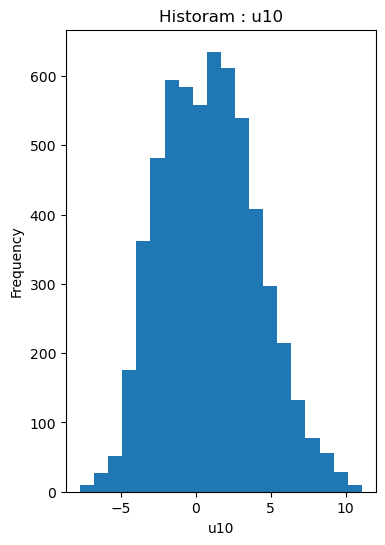

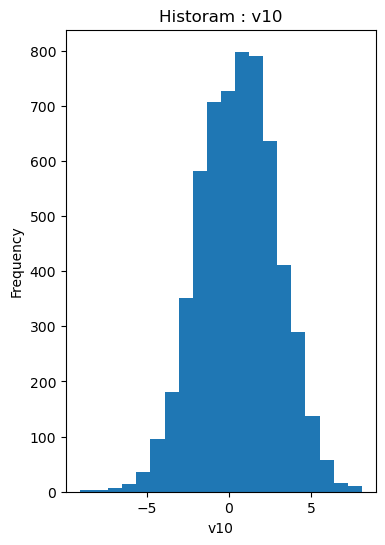

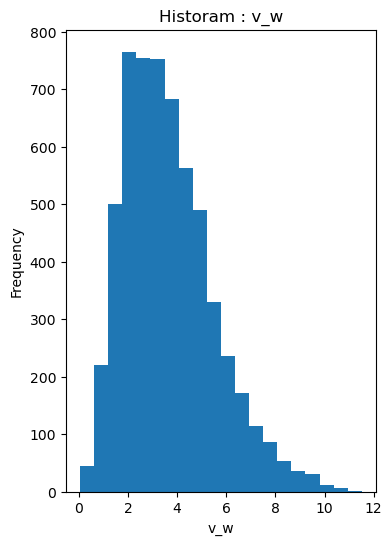

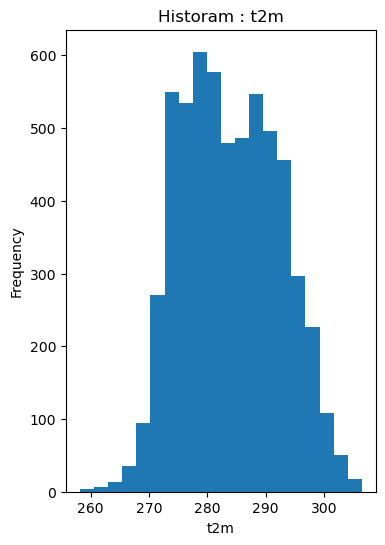

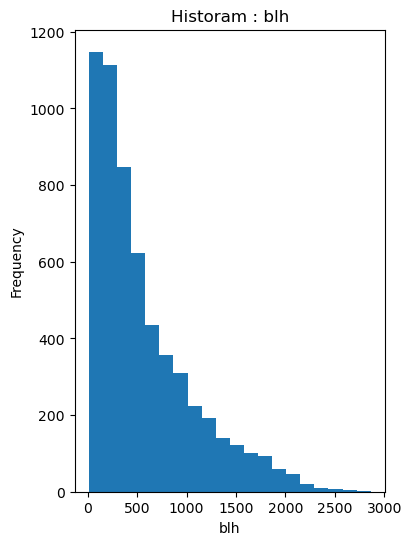

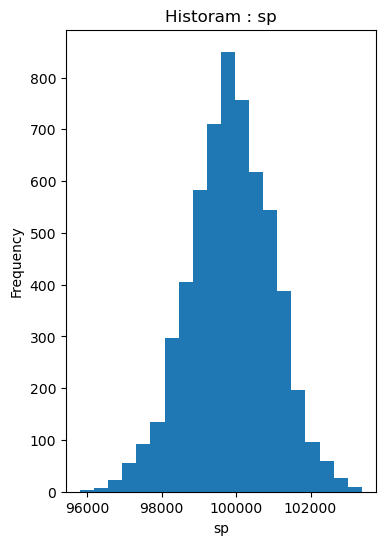

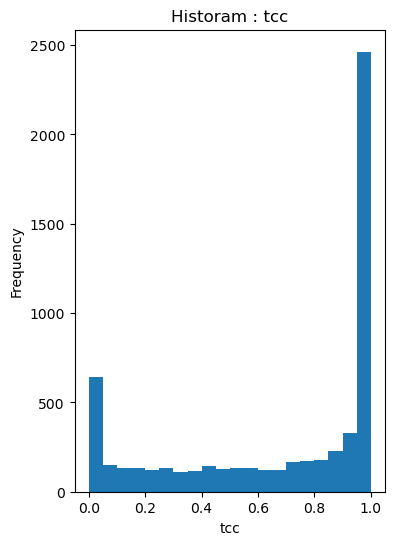

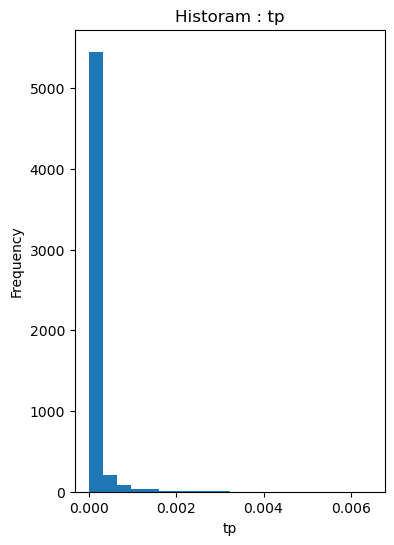

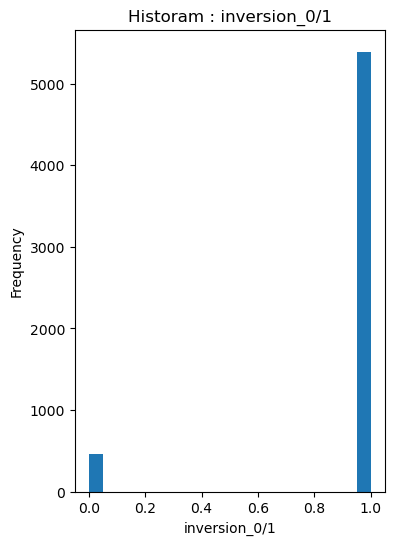

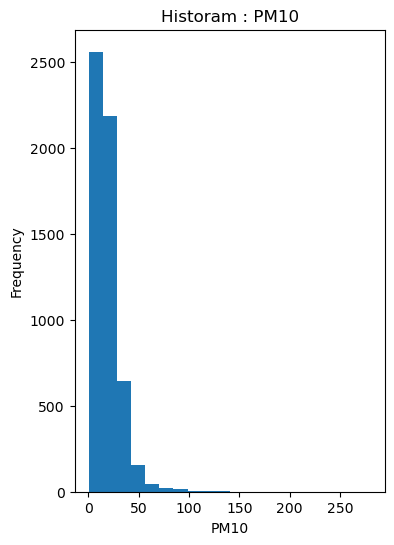

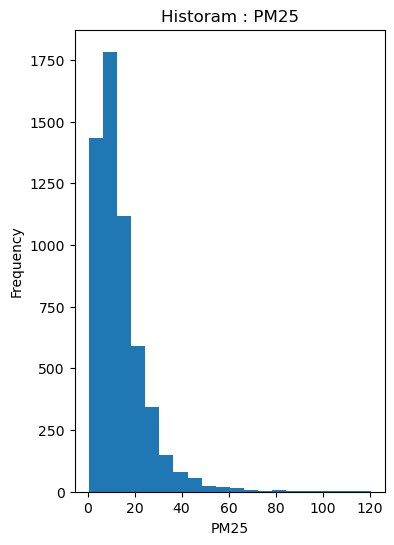

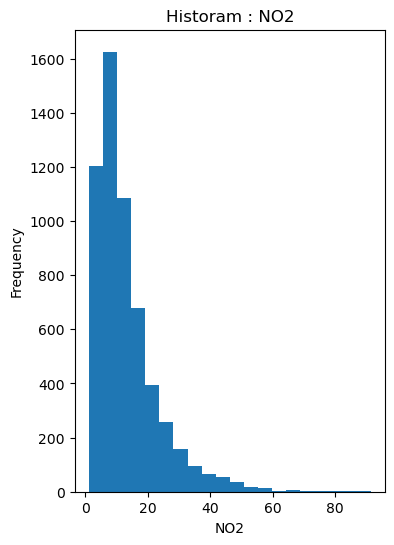

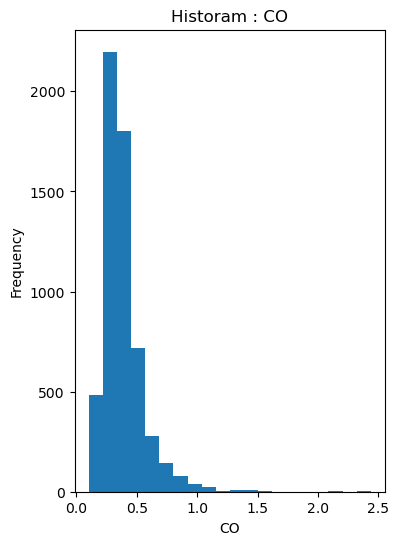

In [522]:
for c in num_col:
    plt.figure(figsize = (4,6))
    plt.hist(main_df[c], bins = 20)
    plt.title(f'Historam : {c}')
    plt.xlabel(c)
    plt.ylabel('Frequency')
    plt.show()
    

#### 2.3.1. Analiza Outliery

Wnioski:

Nie usuwam żadnych outlierów, gdyż sa to dane realne , zdobyte zgodnie ze wskazaniami prawidłowo działjacych stacji meteorologicznych.
Każda wartosć będaca poza zakresem IQR to rzeczywiska obserwacja, więc usunięcie ich byłoby fałszowaniem danych.


In [507]:
# podział na zmienne nurmeryczne i kategoryczne 

num_col = main_df.select_dtypes(include=['int64', 'float64']).columns.tolist()
cat_col = main_df.select_dtypes(include=['object']).columns.tolist()

In [508]:
# nowy słownik do zicznia outlierów wg. nazw kolumn numerycznych 
outlier_counts = {}

# petla for do obliczenia iqr dla kazdej z numerycznych kolum i przypisania sumy outlierow w danej kolimnie + przypisanie do słownika
for c in num_col:
    q1 = main_df[c].quantile(0.25)
    q3 = main_df[c].quantile(0.75)
    iqr = q3-q1
    low = q1 - 1.5*iqr
    high = q3 + 1.5*iqr
    outlier_counts[c] = ((main_df[c] > high) | (main_df[c] < low)).sum()

# tworzymy nowy pandas Series prezetujacy slownik out_liers (w uporzadkowanej tabeli) a następnie transformacja do Data Frame
outliers_df = pd.Series(outlier_counts, name='n_outliers').sort_values(ascending=False)
display(pd.DataFrame(outliers_df))

,n_outliers
tp,1030
inversion_0/1,460
CO,327
NO2,300
blh,246
PM25,246
PM10,239
v_w,110
sp,44
v10,31


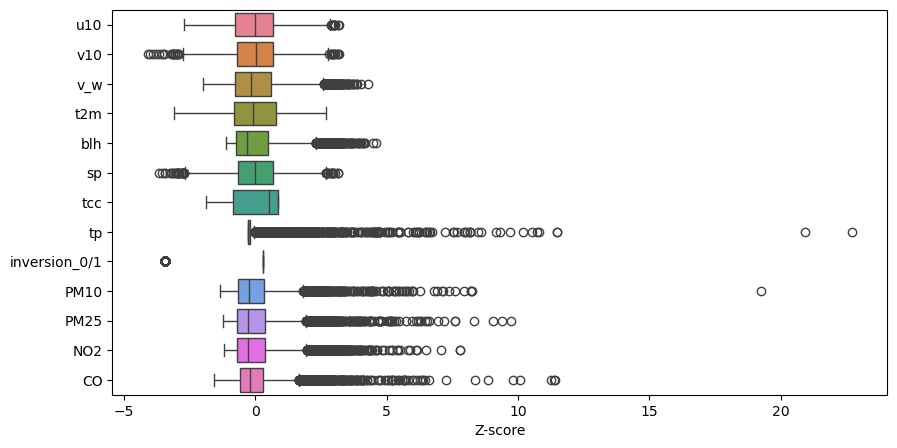


 ************************************************************************************************************************ 



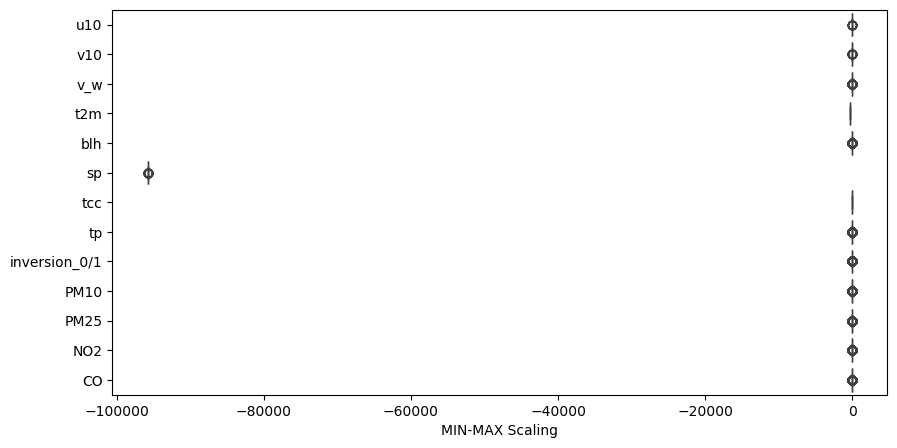

In [496]:
%matplotlib inline

num_df = main_df[num_col].copy()

# przy tworzeniu box plot, stosujemy wzrór na Z-sore tj. normalizaja, standaryzacje danych (przeskalownie)
# dla wyraźniejszego pokazania na wykresie rozkładu danych po przez wizualizację statystyk pozycujnych.
plt.figure(figsize=(10,5))
sns.boxplot((num_df-num_df.mean())/num_df.std(),orient='h')
plt.xlabel('Z-score')
plt.show()


print('\n','*'*120,'\n')

# Zastosowanie min-max scalin dla danych 
plt.figure(figsize=(10,5))
sns.boxplot((num_df-num_df.min())/num_df.max()-num_df.min(),orient='h')
plt.xlabel('MIN-MAX Scaling')
plt.show()
# Nie stosować przy dużych OUTLIERACH


#### 2.3.4 Brakujace wartosci.

Dla brakujacych wartości , przed budowa modeli predkcyjnych bedzie trzeba zastosować IMPUTER

In [639]:
df_nan = main_df[num_col].isna().sum().to_frame(name='nacount')
df_nan

,nacount
u10,0
v10,0
v_w,0
t2m,0
blh,0
sp,0
tcc,0
tp,4
inversion_0/1,0
PM10,207


#### 2.3...... Wnioski 

In [587]:
main_df.loc[main_df['PM10'].isna()]

,city,time,u10,v10,v_w,t2m,blh,sp,tcc,tp,inversion_0/1,PM10,PM25,NO2,CO
0,LD,2023-01-01 00:00:00,5.353332,4.853073,7.225682,285.84010,647.28076,99286.125,0.787537,0.000000e+00,1,NaN,NaN,NaN,NaN
17,LD,2023-01-05 06:00:00,7.809387,0.214203,7.812324,281.15990,1149.78880,98273.440,0.997986,6.465912e-04,1,NaN,NaN,4.5,0.324
192,LD,2023-02-18 00:00:00,10.027954,-1.368240,10.120867,280.92114,1768.66260,98593.500,0.176544,1.335144e-05,1,NaN,NaN,5.2,0.314
193,LD,2023-02-18 06:00:00,9.443954,-1.077957,9.505275,278.25684,1534.17580,98835.940,0.806946,0.000000e+00,1,NaN,NaN,3.7,0.273
194,LD,2023-02-18 12:00:00,8.489548,-0.427383,8.500299,280.28930,1416.27900,98805.375,0.801361,0.000000e+00,1,NaN,NaN,4.7,0.297
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5732,PZ,2024-12-02 00:00:00,-0.187881,2.742279,2.748708,271.05150,105.29970,101048.060,0.000000,0.000000e+00,0,NaN,NaN,16.5,0.638
5733,PZ,2024-12-02 06:00:00,1.445908,3.343948,3.643163,270.91455,234.79541,100854.690,0.253571,0.000000e+00,0,NaN,NaN,18.9,0.636
5734,PZ,2024-12-02 12:00:00,1.416382,3.135681,3.440732,276.53490,348.03247,100676.375,0.851685,4.291534e-06,0,NaN,NaN,18.7,0.418
5735,PZ,2024-12-02 18:00:00,1.313583,3.300400,3.552202,276.53613,217.60533,100555.940,0.918701,0.000000e+00,0,NaN,NaN,34.8,0.568


#### 2.4. Agregeacja main_df
Rozszeżenie o potrzebne dane

#### 2.3.1. Dodanie nowych, niezbędnych kolumn.

In [424]:
# Rozbicie daty/godziny 'time' na szczegóły i zapisanie w nowych kolumnach 

# # rozbiecie 'time' na szczegóły, przypisanie do nowych kolumn wartosći - Rok / Miesiac / Dzień / Dzień_tyg / 
# main_df = main_df.assign(
#     month=main_df['time'].dt.month_name(),
#     year=main_df['time'].dt.year,
#     day=main_df['time'].dt.day,
#     day_of_week=main_df['time'].dt.day_name())
 

# 3. Budowanie Modelu Predycyjnego